# BBC Categorization Pipeline

## 1. Imports And Setup

Run this cell first.


In [1]:
! pip install gensim
! pip install sentence-transformers

In [2]:
import json
import re
from collections import Counter, defaultdict

import matplotlib.pyplot as plt
import numpy as np
import nltk
import nltk.data # Attempting to force early initialization of nltk.data

# Perform nltk downloads immediately after the main nltk import
nltk.download("punkt")
nltk.download("stopwords")
nltk.download("punkt_tab")

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

try:
    from gensim.models import Word2Vec
    GENSIM_AVAILABLE = True
except ImportError as e:
    print(f"Warning: {e}. Word2Vec model will be unavailable.")
    GENSIM_AVAILABLE = False
    Word2Vec = None

try:
    from sentence_transformers import SentenceTransformer
    SENTENCE_TRANSFORMERS_AVAILABLE = True
except ImportError as e:
    print(f"Warning: {e}. Sentence Transformer model will be unavailable.")
    SENTENCE_TRANSFORMERS_AVAILABLE = False
    SentenceTransformer = None

try:
    import tensorflow as tf
    from tensorflow.keras.layers import Dense
    from tensorflow.keras.models import Sequential
    TENSORFLOW_AVAILABLE = True
except ImportError as e:
    print(f"Warning: {e}. Neural Network model will be unavailable.")
    TENSORFLOW_AVAILABLE = False
    tf = None

STOP_WORDS = set(stopwords.words("english"))
RANDOM_STATE = 42

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\sergi\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\sergi\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\sergi\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


## 2. File Registry

Edit this dictionary whenever you add new datasets.


In [3]:
AVAILABLE_FILES = {
    "arts": "bbc_arts_articles.json",
    "business": "bbc_business_articles.json",
    "sport": "bbc_sport_articles.json",
}

AVAILABLE_FILES


{'arts': 'bbc_arts_articles.json',
 'business': 'bbc_business_articles.json',
 'sport': 'bbc_sport_articles.json'}

## 3. Loading Helpers

These functions let you build datasets from as many files and categories as you want.


In [4]:
def load_json_records(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def normalize_article(record, forced_category=None):
    category = (forced_category or record.get("category", "")).strip().lower()
    if not category:
        return None

    return {
        "category": category,
        "title": record.get("title", ""),
        "content": record.get("content", ""),
        "url": record.get("url", ""),
    }


def load_articles_from_source(source):
    path = source["path"]
    forced_category = source.get("category")
    limit = source.get("limit")

    raw_records = load_json_records(path)
    articles = []

    for record in raw_records:
        article = normalize_article(record, forced_category=forced_category)
        if article is not None:
            articles.append(article)

    if limit is not None:
        articles = articles[:limit]

    return articles


def build_sources_from_categories(selected_categories):
    sources = []
    for category in selected_categories:
        if category not in AVAILABLE_FILES:
            raise ValueError(f"Unknown category: {category}. Available categories: {sorted(AVAILABLE_FILES)}")
        sources.append({"path": AVAILABLE_FILES[category], "category": category})
    return sources


def load_dataset(sources):
    dataset = []
    for source in sources:
        dataset.extend(load_articles_from_source(source))
    return dataset


## 4. Preprocessing Helpers

This is the reusable text-cleaning logic extracted from the old notebook.


In [5]:
def preprocess_text(text):
    text = text.lower()
    tokens = word_tokenize(text)
    cleaned_tokens = []

    for token in tokens:
        if re.fullmatch(r"[a-zA-Z]+", token) and token not in STOP_WORDS:
            cleaned_tokens.append(token)

    return cleaned_tokens


def enrich_articles(articles):
    enriched = []
    for article in articles:
        full_text = f"{article['title']} {article['content']}".strip()
        tokens = preprocess_text(full_text)

        new_article = article.copy()
        new_article["full_text"] = full_text
        new_article["tokens"] = tokens
        enriched.append(new_article)

    return enriched


def summarize_dataset(articles):
    counts = Counter(article["category"] for article in articles)
    print("Articles per category:")
    for category, count in sorted(counts.items()):
        print(f"- {category}: {count}")
    print(f"Total articles: {len(articles)}")


def get_common_tokens(articles, top_n=20):
    token_counts = Counter(token for article in articles for token in article["tokens"])
    common_tokens = token_counts.most_common(top_n)
    for token, freq in common_tokens:
        print(f"{token}: {freq}")
    return common_tokens


def get_common_tokens_by_category(articles, top_n=10):
    grouped_tokens = defaultdict(list)
    for article in articles:
        grouped_tokens[article["category"]].extend(article["tokens"])

    result = {}
    for category, tokens in grouped_tokens.items():
        result[category] = Counter(tokens).most_common(top_n)
        print(f"\nTop tokens for {category}:")
        for token, freq in result[category]:
            print(f"{token}: {freq}")

    return result


## 5. Evaluation Helpers

Shared reporting utilities for every model.


In [6]:
def show_evaluation(y_true, y_pred, title, labels=None, cmap="Greens"):
    if labels is None:
        labels = sorted(set(y_true) | set(y_pred))

    print(title)
    print(classification_report(y_true, y_pred, labels=labels))
    print(f"Accuracy: {accuracy_score(y_true, y_pred):.4f}")

    cm = confusion_matrix(y_true, y_pred, labels=labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(cmap=cmap)
    plt.title(title)
    plt.show()


## 6. Dynamic Baseline Classifier

The baseline now learns its buzzwords automatically from the training split by taking the top tokens for each category.


In [7]:
def count_buzzwords(tokens, buzzwords):
    return sum(token in buzzwords for token in tokens)


def extract_top_tokens_by_category(articles, categories, top_n=10):
    learned_keywords = {}

    for category in categories:
        category_tokens = [
            token
            for article in articles
            if article["category"] == category
            for token in article["tokens"]
        ]
        learned_keywords[category] = [
            token for token, _ in Counter(category_tokens).most_common(top_n)
        ]

    return learned_keywords


def print_learned_keywords(keyword_map):
    print("Learned baseline keywords from the training split:")
    for category, keywords in keyword_map.items():
        print(f"- {category}: {keywords}")


def run_baseline(train_articles, test_articles, categories, top_n=10, keyword_map=None):
    if keyword_map is None:
        keyword_map = extract_top_tokens_by_category(train_articles, categories, top_n=top_n)

    missing = [category for category in categories if category not in keyword_map]
    if missing:
        raise ValueError(f"Missing baseline keywords for categories: {missing}")

    print_learned_keywords(keyword_map)

    y_true = [article["category"] for article in test_articles]
    y_pred = []

    for article in test_articles:
        counts = {
            category: count_buzzwords(article["tokens"], keyword_map[category])
            for category in categories
        }
        prediction = max(counts, key=counts.get)
        y_pred.append(prediction)

    show_evaluation(y_true, y_pred, "Baseline", labels=categories, cmap="Blues")
    return y_pred, keyword_map


## 7. TF-IDF Preparation

This prepares the train/test split and the vectorized features.


In [8]:
def split_articles(articles, test_size=0.2):
    article_indices = list(range(len(articles)))
    labels = [article["category"] for article in articles]

    train_indices, test_indices = train_test_split(
        article_indices,
        test_size=test_size,
        random_state=RANDOM_STATE,
        stratify=labels,
    )

    train_articles = [articles[idx] for idx in train_indices]
    test_articles = [articles[idx] for idx in test_indices]

    print(f"Training set size: {len(train_articles)}")
    print(f"Test set size: {len(test_articles)}")

    return train_articles, test_articles


def prepare_features(train_articles, test_articles, min_df=5, max_df=100, ngram_range=(1, 2)):
    X_train = [article["full_text"] for article in train_articles]
    X_test = [article["full_text"] for article in test_articles]
    y_train = [article["category"] for article in train_articles]
    y_test = [article["category"] for article in test_articles]

    vectorizer = TfidfVectorizer(min_df=min_df, max_df=max_df, ngram_range=ngram_range)
    X_train_tfidf = vectorizer.fit_transform(X_train)
    X_test_tfidf = vectorizer.transform(X_test)

    print(f"TF-IDF train shape: {X_train_tfidf.shape}")
    print(f"TF-IDF test shape: {X_test_tfidf.shape}")

    return {
        "vectorizer": vectorizer,
        "train_articles": train_articles,
        "test_articles": test_articles,
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test,
        "X_train_tfidf": X_train_tfidf,
        "X_test_tfidf": X_test_tfidf,
    }


## 8. Logistic Regression

Reusable classical model from the original notebook.


In [9]:
def run_logistic_regression(prepared_data):
    model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
    model.fit(prepared_data["X_train_tfidf"], prepared_data["y_train"])

    y_pred = model.predict(prepared_data["X_test_tfidf"])
    show_evaluation(prepared_data["y_test"], y_pred, "Logistic Regression", labels=list(model.classes_), cmap="Greens")

    return model, y_pred


def average_word_vectors(tokens, word2vec_model):
    vectors = [word2vec_model.wv[token] for token in tokens if token in word2vec_model.wv]
    if not vectors:
        return np.zeros(word2vec_model.vector_size)
    return np.mean(vectors, axis=0)


def prepare_word2vec_features(train_articles, test_articles, vector_size=100, window=5, min_count=2, sg=1):
    if not GENSIM_AVAILABLE:
        raise ImportError("gensim is not installed in this environment.")

    train_sentences = [article["tokens"] for article in train_articles]
    test_sentences = [article["tokens"] for article in test_articles]

    word2vec_model = Word2Vec(
        sentences=train_sentences,
        vector_size=vector_size,
        window=window,
        min_count=min_count,
        sg=sg,
        workers=1,
        seed=RANDOM_STATE,
    )

    X_train_w2v = np.vstack([average_word_vectors(tokens, word2vec_model) for tokens in train_sentences])
    X_test_w2v = np.vstack([average_word_vectors(tokens, word2vec_model) for tokens in test_sentences])
    y_train = [article["category"] for article in train_articles]
    y_test = [article["category"] for article in test_articles]

    print(f"Word2Vec train shape: {X_train_w2v.shape}")
    print(f"Word2Vec test shape: {X_test_w2v.shape}")

    return {
        "word2vec_model": word2vec_model,
        "X_train_w2v": X_train_w2v,
        "X_test_w2v": X_test_w2v,
        "y_train": y_train,
        "y_test": y_test,
        "train_articles": train_articles,
        "test_articles": test_articles,
    }


def run_word2vec_classifier(word2vec_data):
    model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
    model.fit(word2vec_data["X_train_w2v"], word2vec_data["y_train"])

    y_pred = model.predict(word2vec_data["X_test_w2v"])
    show_evaluation(word2vec_data["y_test"], y_pred, "Word2Vec + Logistic Regression", labels=list(model.classes_), cmap="PuBu")

    return model, y_pred


def prepare_sentence_transformer_features(
    train_articles,
    test_articles,
    model_name="distiluse-base-multilingual-cased-v2",
    batch_size=32,
    normalize_embeddings=True,
):
    if not SENTENCE_TRANSFORMERS_AVAILABLE:
        raise ImportError("sentence-transformers is not installed in this environment.")

    encoder = SentenceTransformer(model_name)
    X_train = [article["full_text"] for article in train_articles]
    X_test = [article["full_text"] for article in test_articles]

    X_train_st = encoder.encode(
        X_train,
        batch_size=batch_size,
        show_progress_bar=True,
        normalize_embeddings=normalize_embeddings,
    )
    X_test_st = encoder.encode(
        X_test,
        batch_size=batch_size,
        show_progress_bar=True,
        normalize_embeddings=normalize_embeddings,
    )

    y_train = [article["category"] for article in train_articles]
    y_test = [article["category"] for article in test_articles]

    print(f"Sentence Transformer model: {model_name}")
    print(f"Sentence Transformer train shape: {X_train_st.shape}")
    print(f"Sentence Transformer test shape: {X_test_st.shape}")

    return {
        "encoder": encoder,
        "model_name": model_name,
        "X_train_st": X_train_st,
        "X_test_st": X_test_st,
        "y_train": y_train,
        "y_test": y_test,
        "train_articles": train_articles,
        "test_articles": test_articles,
    }


def run_sentence_transformer_classifier(sentence_transformer_data):
    model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
    model.fit(sentence_transformer_data["X_train_st"], sentence_transformer_data["y_train"])

    y_pred = model.predict(sentence_transformer_data["X_test_st"])
    show_evaluation(
        sentence_transformer_data["y_test"],
        y_pred,
        "Sentence Transformer + Logistic Regression",
        labels=list(model.classes_),
        cmap="Purples",
    )

    return model, y_pred


## 9. Neural Network

This version supports both binary and multi-class classification.


In [10]:
def build_neural_network(input_dim, num_classes):
    model = Sequential()
    model.add(Dense(128, activation="relu", input_shape=(input_dim,)))
    model.add(Dense(64, activation="relu"))

    if num_classes == 2:
        model.add(Dense(1, activation="sigmoid"))
        model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    else:
        model.add(Dense(num_classes, activation="softmax"))
        model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

    return model


def run_neural_network(prepared_data, epochs=10, batch_size=32):
    if not TENSORFLOW_AVAILABLE:
        raise ImportError("TensorFlow is not installed in this environment.")

    label_encoder = LabelEncoder()
    y_train_encoded = label_encoder.fit_transform(prepared_data["y_train"])
    y_test_encoded = label_encoder.transform(prepared_data["y_test"])

    X_train_dense = prepared_data["X_train_tfidf"].toarray()
    X_test_dense = prepared_data["X_test_tfidf"].toarray()

    num_classes = len(label_encoder.classes_)
    model = build_neural_network(prepared_data["X_train_tfidf"].shape[1], num_classes)
    model.summary()

    history = model.fit(
        X_train_dense,
        y_train_encoded,
        epochs=epochs,
        batch_size=batch_size,
        validation_split=0.2,
        verbose=1,
    )

    y_pred_raw = model.predict(X_test_dense)

    if num_classes == 2:
        y_pred_encoded = (y_pred_raw > 0.5).astype(int).flatten()
    else:
        y_pred_encoded = y_pred_raw.argmax(axis=1)

    y_pred = label_encoder.inverse_transform(y_pred_encoded)
    show_evaluation(prepared_data["y_test"], y_pred, "Neural Network", labels=list(label_encoder.classes_), cmap="Oranges")

    return model, history, y_pred, label_encoder


## 10. Main Pipeline Runner

This is the one function you can reuse at the end of the notebook for every experiment.


In [11]:
def run_pipeline(
    sources,
    run_baseline_model=True,
    run_logistic_model=True,
    run_word2vec_model=False,
    run_sentence_transformer_model=False,
    run_neural_model=False,
    show_dataset_summary=True,
    show_top_tokens=False,
    show_top_tokens_by_category=False,
    top_n_tokens=20,
    baseline_top_n=10,
    baseline_keywords=None,
    tfidf_kwargs=None,
    word2vec_kwargs=None,
    sentence_transformer_kwargs=None,
    nn_kwargs=None,
):
    tfidf_kwargs = tfidf_kwargs or {}
    word2vec_kwargs = word2vec_kwargs or {}
    sentence_transformer_kwargs = sentence_transformer_kwargs or {}
    nn_kwargs = nn_kwargs or {}

    articles = load_dataset(sources)
    articles = enrich_articles(articles)
    categories = sorted({article["category"] for article in articles})

    if show_dataset_summary:
        summarize_dataset(articles)

    if show_top_tokens:
        print(f"\nTop {top_n_tokens} tokens in the whole dataset:")
        get_common_tokens(articles, top_n=top_n_tokens)

    if show_top_tokens_by_category:
        get_common_tokens_by_category(articles, top_n=top_n_tokens)

    results = {
        "articles": articles,
        "categories": categories,
        "sources": sources,
    }

    print("\n=== Train/Test Split ===")
    test_size = tfidf_kwargs.pop("test_size", 0.2)
    train_articles, test_articles = split_articles(articles, test_size=test_size)
    results["train_articles"] = train_articles
    results["test_articles"] = test_articles
    results["test_size"] = test_size

    if run_baseline_model:
        print("\n=== Baseline ===")
        baseline_predictions, learned_keywords = run_baseline(
            train_articles,
            test_articles,
            categories,
            top_n=baseline_top_n,
            keyword_map=baseline_keywords,
        )
        results["baseline_predictions"] = baseline_predictions
        results["baseline_keywords"] = learned_keywords

    if run_logistic_model or run_neural_model:
        print("\n=== Feature Preparation ===")
        prepared_data = prepare_features(train_articles, test_articles, **tfidf_kwargs)
        results["prepared_data"] = prepared_data

    if run_logistic_model:
        print("\n=== Logistic Regression ===")
        logistic_model, logistic_predictions = run_logistic_regression(prepared_data)
        results["logistic_model"] = logistic_model
        results["logistic_predictions"] = logistic_predictions

    if run_word2vec_model:
        print("\n=== Word2Vec ===")
        word2vec_data = prepare_word2vec_features(train_articles, test_articles, **word2vec_kwargs)
        word2vec_model, word2vec_predictions = run_word2vec_classifier(word2vec_data)
        results["word2vec_data"] = word2vec_data
        results["word2vec_model"] = word2vec_model
        results["word2vec_predictions"] = word2vec_predictions

    if run_sentence_transformer_model:
        print("\n=== Sentence Transformer ===")
        sentence_transformer_data = prepare_sentence_transformer_features(
            train_articles,
            test_articles,
            **sentence_transformer_kwargs,
        )
        sentence_transformer_model, sentence_transformer_predictions = run_sentence_transformer_classifier(sentence_transformer_data)
        results["sentence_transformer_data"] = sentence_transformer_data
        results["sentence_transformer_model"] = sentence_transformer_model
        results["sentence_transformer_predictions"] = sentence_transformer_predictions

    if run_neural_model:
        print("\n=== Neural Network ===")
        neural_model, neural_history, neural_predictions, label_encoder = run_neural_network(prepared_data, **nn_kwargs)
        results["neural_model"] = neural_model
        results["neural_history"] = neural_history
        results["neural_predictions"] = neural_predictions
        results["label_encoder"] = label_encoder

    return results


## 11. Pipelines


### Arts + Business


Articles per category:
- arts: 1008
- business: 993
Total articles: 2001

=== Train/Test Split ===
Training set size: 1600
Test set size: 401

=== Baseline ===
Learned baseline keywords from the training split:
- arts: ['said', 'bbc', 'people', 'theatre', 'art', 'work', 'new', 'artist', 'says', 'one']
- business: ['said', 'us', 'trump', 'also', 'says', 'would', 'year', 'new', 'people', 'uk']
Baseline
              precision    recall  f1-score   support

        arts       0.87      0.89      0.88       202
    business       0.89      0.87      0.88       199

    accuracy                           0.88       401
   macro avg       0.88      0.88      0.88       401
weighted avg       0.88      0.88      0.88       401

Accuracy: 0.8803


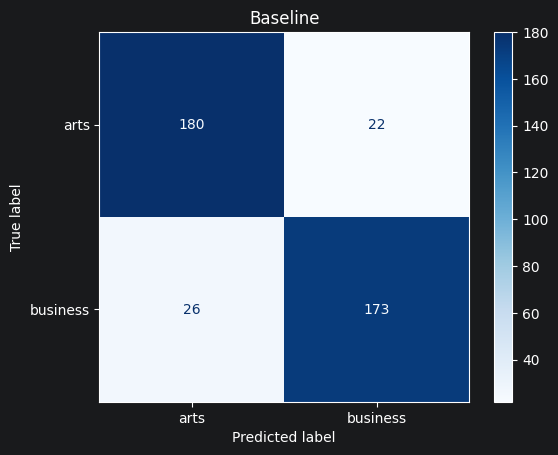


=== Feature Preparation ===
TF-IDF train shape: (1600, 36359)
TF-IDF test shape: (401, 36359)

=== Logistic Regression ===
Logistic Regression
              precision    recall  f1-score   support

        arts       0.99      0.99      0.99       202
    business       0.99      0.99      0.99       199

    accuracy                           0.99       401
   macro avg       0.99      0.99      0.99       401
weighted avg       0.99      0.99      0.99       401

Accuracy: 0.9900


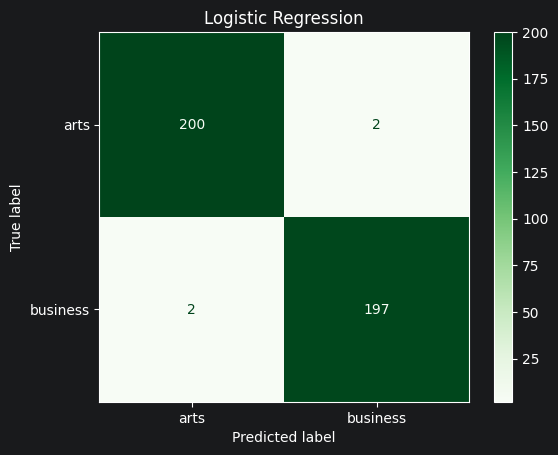


=== Word2Vec ===
Word2Vec train shape: (1600, 100)
Word2Vec test shape: (401, 100)
Word2Vec + Logistic Regression
              precision    recall  f1-score   support

        arts       0.99      0.98      0.99       202
    business       0.98      0.99      0.98       199

    accuracy                           0.99       401
   macro avg       0.99      0.99      0.99       401
weighted avg       0.99      0.99      0.99       401

Accuracy: 0.9850


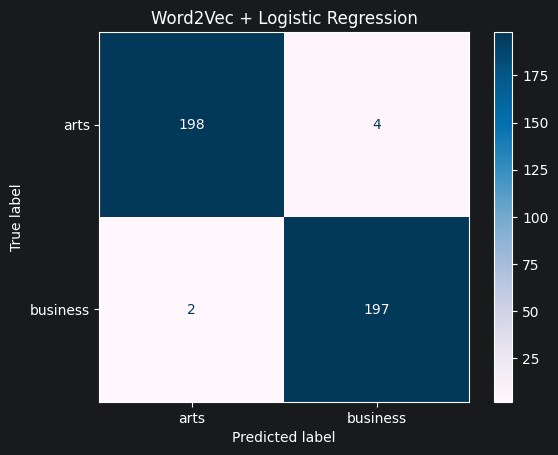


=== Sentence Transformer ===


modules.json:   0%|          | 0.00/341 [00:00<?, ?B/s]

C:\Users\sergi\AppData\Local\Programs\Python\Python313\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\sergi\.cache\huggingface\hub\models--sentence-transformers--distiluse-base-multilingual-cased-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

config.json:   0%|          | 0.00/114 [00:00<?, ?B/s]

2_Dense/model.safetensors:   0%|          | 0.00/1.58M [00:00<?, ?B/s]

Batches:   0%|          | 0/50 [00:00<?, ?it/s]

Batches:   0%|          | 0/13 [00:00<?, ?it/s]

Sentence Transformer model: distiluse-base-multilingual-cased-v2
Sentence Transformer train shape: (1600, 512)
Sentence Transformer test shape: (401, 512)
Sentence Transformer + Logistic Regression
              precision    recall  f1-score   support

        arts       0.98      0.98      0.98       202
    business       0.98      0.98      0.98       199

    accuracy                           0.98       401
   macro avg       0.98      0.98      0.98       401
weighted avg       0.98      0.98      0.98       401

Accuracy: 0.9800


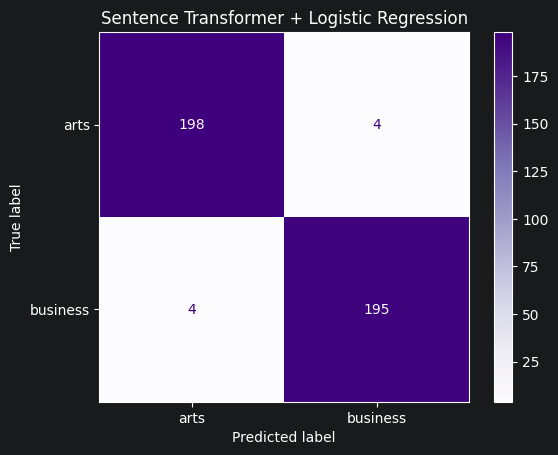


=== Neural Network ===


C:\Users\sergi\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │     4,654,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,662,401 (17.79 MB)

 Trainable params: 4,662,401 (17.79 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9617 - loss: 0.3942 - val_accuracy: 0.9906 - val_loss: 0.0824
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9969 - loss: 0.0198 - val_accuracy: 0.9875 - val_loss: 0.0332
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9984 - loss: 0.0050 - val_accuracy: 0.9906 - val_loss: 0.0280
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 1.0000 - loss: 0.0019 - val_accuracy: 0.9906 - val_loss: 0.0252
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 1.0000 - loss: 0.0015 - val_accuracy: 0.9906 - val_loss: 0.0233
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 1.0000 - loss: 0.0011 - val_accuracy: 0.9906 - val_loss: 0.0214
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 1.0000 - loss: 9.4140e-04 - val_accuracy: 0.9906 - val_loss: 0.0201
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 1.0000 - loss: 5.2746e-04 - val_accuracy: 0.

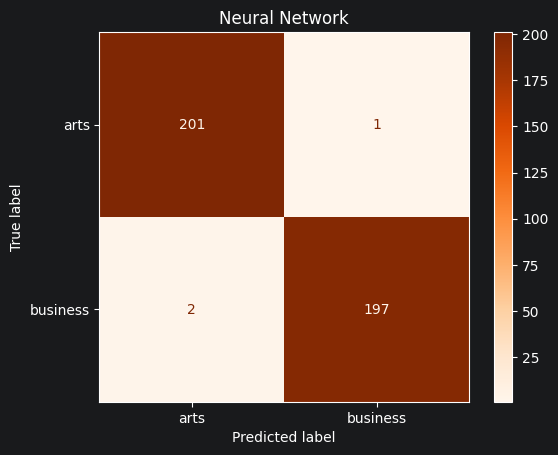

In [12]:
pipeline_arts_business = run_pipeline(
    sources=[
        {"path": AVAILABLE_FILES["arts"], "category": "arts"},
        {"path": AVAILABLE_FILES["business"], "category": "business"},
    ],
    run_baseline_model=True,
    run_logistic_model=True,
    run_word2vec_model=True,
    run_neural_model=True,
    run_sentence_transformer_model=True,
    show_top_tokens=False,
)


### Business + Sport


Articles per category:
- business: 993
- sport: 986
Total articles: 1979

=== Train/Test Split ===
Training set size: 1583
Test set size: 396

=== Baseline ===
Learned baseline keywords from the training split:
- business: ['said', 'us', 'trump', 'would', 'also', 'says', 'year', 'new', 'people', 'uk']
- sport: ['said', 'league', 'first', 'world', 'one', 'team', 'last', 'two', 'england', 'game']
Baseline
              precision    recall  f1-score   support

    business       0.91      0.95      0.93       199
       sport       0.95      0.90      0.93       197

    accuracy                           0.93       396
   macro avg       0.93      0.93      0.93       396
weighted avg       0.93      0.93      0.93       396

Accuracy: 0.9293


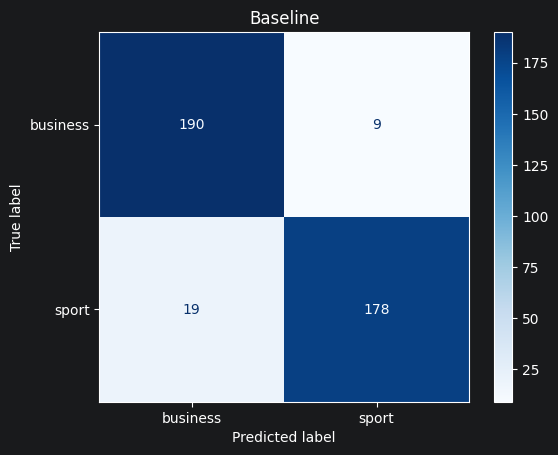


=== Feature Preparation ===
TF-IDF train shape: (1583, 42379)
TF-IDF test shape: (396, 42379)

=== Logistic Regression ===
Logistic Regression
              precision    recall  f1-score   support

    business       0.99      1.00      0.99       199
       sport       1.00      0.99      0.99       197

    accuracy                           0.99       396
   macro avg       1.00      0.99      0.99       396
weighted avg       0.99      0.99      0.99       396

Accuracy: 0.9949


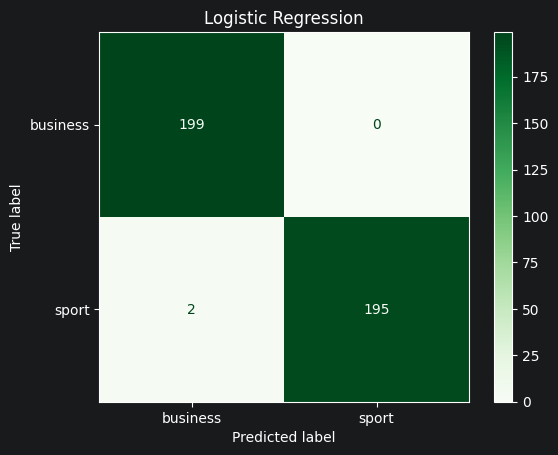


=== Word2Vec ===
Word2Vec train shape: (1583, 100)
Word2Vec test shape: (396, 100)
Word2Vec + Logistic Regression
              precision    recall  f1-score   support

    business       0.99      1.00      0.99       199
       sport       1.00      0.98      0.99       197

    accuracy                           0.99       396
   macro avg       0.99      0.99      0.99       396
weighted avg       0.99      0.99      0.99       396

Accuracy: 0.9924


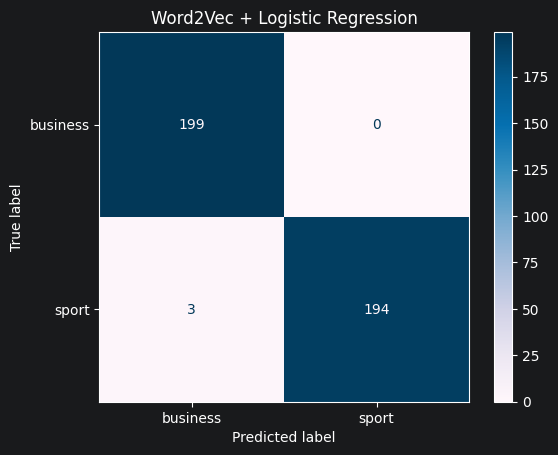


=== Neural Network ===


C:\Users\sergi\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │     5,424,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,432,961 (20.73 MB)

 Trainable params: 5,432,961 (20.73 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9194 - loss: 0.4020 - val_accuracy: 0.9968 - val_loss: 0.0896
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9976 - loss: 0.0207 - val_accuracy: 0.9968 - val_loss: 0.0172
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9992 - loss: 0.0033 - val_accuracy: 1.0000 - val_loss: 0.0130
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9992 - loss: 0.0020 - val_accuracy: 1.0000 - val_loss: 0.0112
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9992 - loss: 0.0015 - val_accuracy: 1.0000 - val_loss: 0.0101
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9992 - loss: 0.0012 - val_accuracy: 1.0000 - val_loss: 0.0092
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 1.0000 - loss: 9.3670e-04 - val_accuracy: 1.0000 - val_loss: 0.0089
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 1.0000 - loss: 7.6119e-04 - val_accuracy: 1.

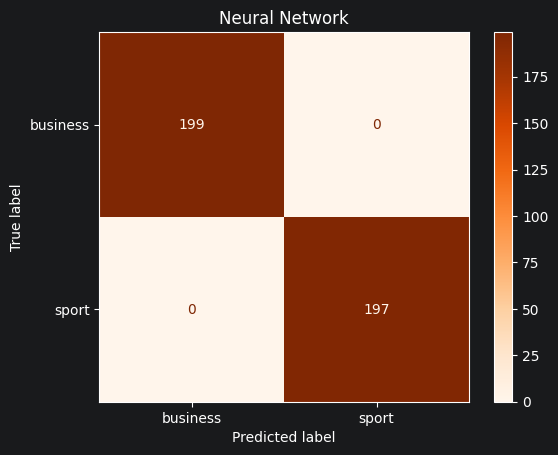

In [13]:
selected_categories = ["business", "sport"]
selected_sources = build_sources_from_categories(selected_categories)

pipeline_from_category_list = run_pipeline(
    sources=selected_sources,
    run_baseline_model=True,
    run_logistic_model=True,
    run_word2vec_model=True,
    run_neural_model=True,
    run_sentence_transformer_model=True,
)


### Arts + Business + Sport


Articles per category:
- arts: 1008
- business: 993
- sport: 986
Total articles: 2987

=== Train/Test Split ===
Training set size: 2389
Test set size: 598

=== Baseline ===
Learned baseline keywords from the training split:
- arts: ['said', 'bbc', 'people', 'theatre', 'art', 'work', 'new', 'artist', 'says', 'one']
- business: ['said', 'us', 'trump', 'also', 'says', 'would', 'year', 'new', 'people', 'uk']
- sport: ['said', 'league', 'england', 'first', 'world', 'one', 'team', 'last', 'two', 'season']
Baseline
              precision    recall  f1-score   support

        arts       0.85      0.88      0.86       202
    business       0.82      0.86      0.84       199
       sport       0.96      0.87      0.91       197

    accuracy                           0.87       598
   macro avg       0.87      0.87      0.87       598
weighted avg       0.87      0.87      0.87       598

Accuracy: 0.8696


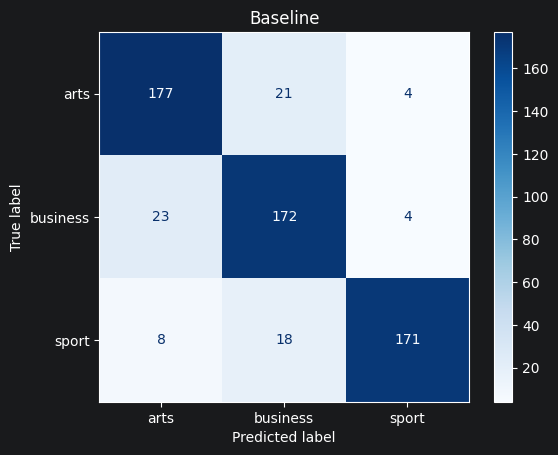


=== Feature Preparation ===
TF-IDF train shape: (2389, 54511)
TF-IDF test shape: (598, 54511)

=== Logistic Regression ===
Logistic Regression
              precision    recall  f1-score   support

        arts       0.99      0.99      0.99       202
    business       0.98      0.98      0.98       199
       sport       0.99      0.99      0.99       197

    accuracy                           0.99       598
   macro avg       0.99      0.99      0.99       598
weighted avg       0.99      0.99      0.99       598

Accuracy: 0.9883


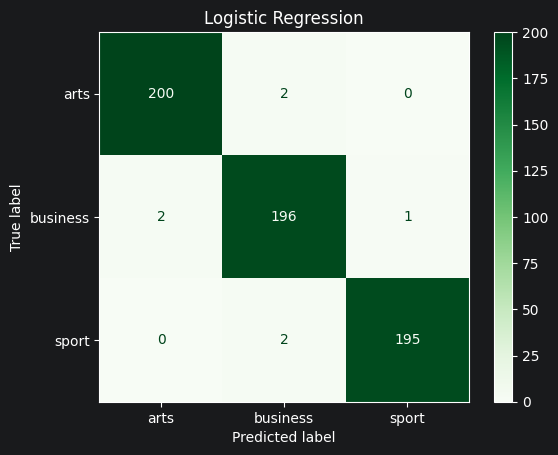


=== Word2Vec ===
Word2Vec train shape: (2389, 100)
Word2Vec test shape: (598, 100)
Word2Vec + Logistic Regression
              precision    recall  f1-score   support

        arts       0.99      0.98      0.98       202
    business       0.97      0.99      0.98       199
       sport       1.00      0.98      0.99       197

    accuracy                           0.98       598
   macro avg       0.98      0.98      0.98       598
weighted avg       0.98      0.98      0.98       598

Accuracy: 0.9833


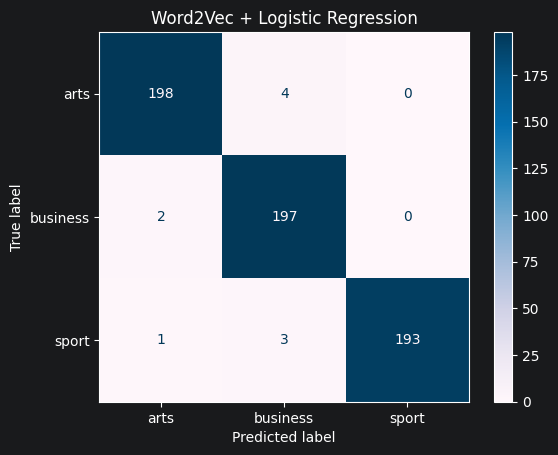


=== Sentence Transformer ===


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

Batches:   0%|          | 0/75 [00:00<?, ?it/s]

In [ ]:
pipeline_arts_business_sport = run_pipeline(
    sources=[
        {"path": AVAILABLE_FILES["arts"], "category": "arts"},
        {"path": AVAILABLE_FILES["business"], "category": "business"},
        {"path": AVAILABLE_FILES["sport"], "category": "sport"},
    ],
    run_baseline_model=True,
    run_logistic_model=True,
    run_word2vec_model=True,
    run_neural_model=True,
    run_sentence_transformer_model=True,
    show_top_tokens=False,
)


### Fully Custom Pipeline Template


Articles per category:
- arts: 1008
- business: 993
- sport: 300
Total articles: 2301

Top 15 tokens in the whole dataset:
said: 11613
us: 5730
bbc: 3570
also: 3562
says: 3509
would: 3470
people: 3457
new: 3256
one: 3038
year: 2930
world: 2852
years: 2459
trump: 2452
first: 2292
work: 2157

=== Train/Test Split ===
Training set size: 1840
Test set size: 461

=== Baseline ===
Learned baseline keywords from the training split:
- arts: ['said', 'bbc', 'people', 'theatre', 'art', 'work', 'new', 'artist', 'says', 'one']
- business: ['said', 'us', 'trump', 'also', 'says', 'would', 'year', 'new', 'people', 'uk']
- sport: ['world', 'said', 'sport', 'team', 'bbc', 'two', 'first', 'one', 'england', 'olympic']
Baseline
              precision    recall  f1-score   support

        arts       0.86      0.86      0.86       202
    business       0.86      0.85      0.86       199
       sport       0.79      0.80      0.79        60

    accuracy                           0.85       461
   macro a

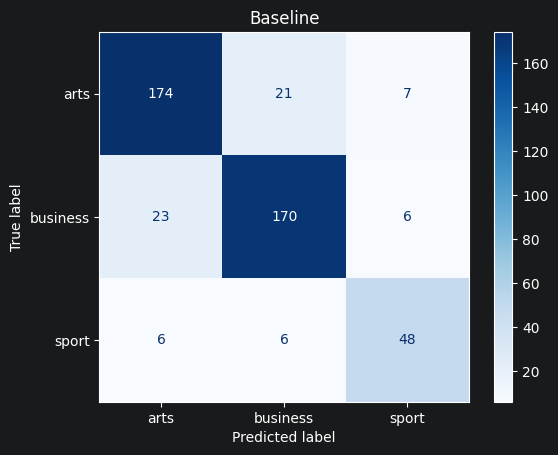


=== Feature Preparation ===
TF-IDF train shape: (1840, 41611)
TF-IDF test shape: (461, 41611)

=== Logistic Regression ===
Logistic Regression
              precision    recall  f1-score   support

        arts       0.97      1.00      0.98       202
    business       0.98      0.99      0.99       199
       sport       1.00      0.88      0.94        60

    accuracy                           0.98       461
   macro avg       0.98      0.96      0.97       461
weighted avg       0.98      0.98      0.98       461

Accuracy: 0.9783


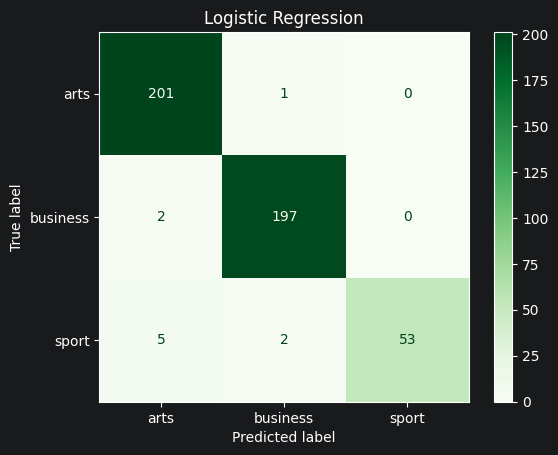


=== Word2Vec ===
Word2Vec train shape: (1840, 100)
Word2Vec test shape: (461, 100)
Word2Vec + Logistic Regression
              precision    recall  f1-score   support

        arts       0.99      0.98      0.98       202
    business       0.97      0.99      0.98       199
       sport       1.00      0.95      0.97        60

    accuracy                           0.98       461
   macro avg       0.99      0.97      0.98       461
weighted avg       0.98      0.98      0.98       461

Accuracy: 0.9805


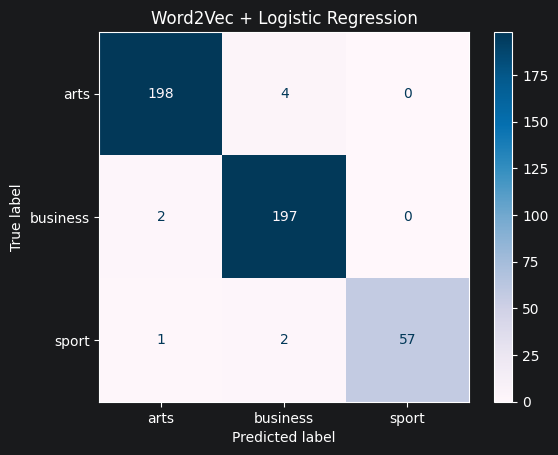


=== Sentence Transformer ===


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

Batches:   0%|          | 0/58 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [15]:
custom_sources = [
    {"path": "bbc_arts_articles.json", "category": "arts"},
    {"path": "bbc_business_articles.json", "category": "business"},
    {"path": "bbc_sport_articles.json", "category": "sport", "limit": 300},
]

custom_pipeline = run_pipeline(
    sources=custom_sources,
    run_baseline_model=True,
    run_logistic_model=True,
    run_word2vec_model=True,
    run_sentence_transformer_model=True,
    run_neural_model=True,
    show_dataset_summary=True,
    show_top_tokens=True,
    show_top_tokens_by_category=False,
    top_n_tokens=15,
    tfidf_kwargs={
        "test_size": 0.2,
        "min_df": 5,
        "max_df": 100,
        "ngram_range": (1, 2),
    },
    word2vec_kwargs={
        "vector_size": 100,
        "window": 5,
        "min_count": 2,
        "sg": 1,
    },
    sentence_transformer_kwargs={
        "model_name": "distiluse-base-multilingual-cased-v2",
        "batch_size": 32,
        "normalize_embeddings": True,
    },
    nn_kwargs={
        "epochs": 10,
        "batch_size": 32,
    },
)
